# GLANCE Palm Cohort  Vitiligo Hand/Palm + Healthy Baseline (Notebook 5)

## Clinical Objective
Curate confirmed **Vitiligo** cases isolated to hand/palm/finger presentation, paired with a genuine **healthy palm** control baseline, for the GLANCE Palm Cohort.

## Datasets Used
| Source | Link | Used for |
|---|---|---|
| Human Skin Diseases Image Dataset (youssefmohmmed) | https://www.kaggle.com/datasets/youssefmohmmed/human-skin-diseases-image | Vitiligo hand/palm cases  manual triage |
| Vitiligo Dataset (shinynose) | https://www.kaggle.com/datasets/shinynose/vitiligo | Vitiligo hand/palm cases  manual triage + Healthy palm baseline |
| DermaCon-IN metadata (shahrozkhalid11/vitiligo-v2) | https://www.kaggle.com/datasets/shahrozkhalid11/vitiligo-v2 | Vitiligo hand/palm cases  clinical metadata confirmed |

## Workflow Summary
1. **youssefmohmmed**: 796 Vitiligo images reviewed manually → **81** confirmed hand/palm.
2. **DermaCon-IN**: `Body_part` metadata field filtered for hand/palm/finger/wrist → **124** confirmed.
3. **shinynose**: 2,057 Vitiligo images reviewed manually → **96** confirmed hand/palm.
4. **Healthy baseline**: shinynose's 1,528 "healthy" images passed through MediaPipe hand detection (1,221 flagged), then manually reviewed → **802** confirmed healthy hand/palm images.

## Output Volume
- `vitiligo_hand`: 301 verified images
- `healthy_hand`: 802 verified images
- **Total**: 1,103 verified images

In [3]:
# Step 1: List input files
from pathlib import Path
for p in Path("/kaggle/input").rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/input/datasets
/kaggle/input/datasets/youssefmohmmed
/kaggle/input/datasets/shahrozkhalid11
/kaggle/input/datasets/shinynose
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2
/kaggle/input/datasets/shinynose/vitiligo
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/test
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/train
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Tinea
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Eczema
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Actinic_Keratosis
/kaggle/input/da

In [4]:
# Step 2: Locate all three source datasets
yousaf_root = Path("/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease")
shinynose_root = Path("/kaggle/input/datasets/shinynose/vitiligo/vitiligo")
dermacon_root = Path("/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2")

print("youssefmohmmed exists:", yousaf_root.exists())
print("shinynose exists:", shinynose_root.exists())
print("DermaCon-IN exists:", dermacon_root.exists())

youssefmohmmed exists: True
shinynose exists: True
DermaCon-IN exists: True


In [7]:
# Step 3: Check for a Healthy/Normal category in youssefmohmmed
normal_files = [p for p in yousaf_root.rglob("*") if p.is_file() and p.parent.name == "Normal"]
print(f"youssefmohmmed 'Normal' category: {len(normal_files)} images")

youssefmohmmed 'Normal' category: 1835 images


In [10]:
# Step 4: Fix path - check one level up for healthy folder
shinynose_parent = Path("/kaggle/input/datasets/shinynose/vitiligo")

for p in shinynose_parent.iterdir():
    print(p)

/kaggle/input/datasets/shinynose/vitiligo/healthy
/kaggle/input/datasets/shinynose/vitiligo/vitiligo


In [11]:
# Step 4b: Count healthy images at correct path
healthy_shinynose = [p for p in shinynose_parent.rglob("*") if p.is_file() and p.parent.name.lower() == "healthy"]
print(f"shinynose 'healthy' category: {len(healthy_shinynose)} images")

shinynose 'healthy' category: 1528 images


In [9]:
# Step 5: Check DermaCon-IN for healthy/normal-type labels
print(df_full['Main_class'].unique())
print(df_full[df_full['Main_class'] == 'No Definite Diagnosis']['Disease_label'].value_counts())

['Infectious Disorders' 'Skin Appendages Disorders' 'Pigmentary Disorders'
 'Inflammatory Disorders' 'Other skin disorders' 'Neoplasms and tumors'
 'No Definite Diagnosis' 'Keratanisation Disorders']
Disease_label
No Definite Diagnosis    37
Name: count, dtype: int64


In [15]:
# Step 6: MediaPipe hand detection on shinynose healthy images
import subprocess
subprocess.run(["pip", "install", "-q", "mediapipe", "--break-system-packages"])
subprocess.run(["wget", "-q", "-O", "/kaggle/working/hand_landmarker.task",
                 "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"])

import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision
import cv2
import pandas as pd

base_options = mp_tasks.BaseOptions(model_asset_path='/kaggle/working/hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1, min_hand_detection_confidence=0.6)
detector = vision.HandLandmarker.create_from_options(options)

results_list = []
for i, img_path in enumerate(healthy_shinynose):
    img_cv = cv2.imread(str(img_path))
    if img_cv is None:
        results_list.append({"index": i, "path": str(img_path), "hand_detected": False})
        continue
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    results_list.append({"index": i, "path": str(img_path), "hand_detected": len(result.hand_landmarks) > 0})

df_hand_detect_shinynose = pd.DataFrame(results_list)
detected_files_shinynose = df_hand_detect_shinynose[df_hand_detect_shinynose['hand_detected'] == True].reset_index(drop=True)
print(f"Hand detected: {len(detected_files_shinynose)} / {len(df_hand_detect_shinynose)}")

W0000 00:00:1789887306.891671     203 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789887306.916577     204 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Hand detected: 1221 / 1528


In [23]:
# Step 7 : Compile all excluded indices from manual review across all batches
batch1 = [0,5,10,13,14,20,22,23,27,31,34,40,45,46,49,50,53,55,56,59,61,65,67,71,72,77,85,86,88,91,93,103,104,106,
          107,121,124,127,131,133,136,137,140,142,145,157,159,162,167,170,177,178,180,184,185,198]

batch2 = [200,203,205,206,209,211,215,218,221,222,223,224,227,228,243,246,249,250,251,255,256,266,271,272,273,
          277,281,288,290,293,294,295,301,304,309,312,313,317,320,322,323,324,326,331,332,334,335,336,337,341,
          343,344,347,352,357,358,364,365,370,371,374,379,382,385,387,392,394,397,398,400,401,404,409,410,413,
          416,420,422,423,425,427,428,429,435,437,438,439,440,441,442,443,445,448,450,455,459,460,465,468,469,
          470,479,482,486,487,489,491,496,500,504,507,510,511,513,514,515,516,517,520,521,526,528,530,537,541,
          545,546,547,549,542,555,558,560,566,568,571,572,575,578,582,587,590,592,595,596,598,599,602,604,606,
          608,609,614,618,620,621,623,630,633,640,645,649,652,655,658,663,664,665,666,667,668,669,672,674,677,
          682,683,684,685,690,691,694,696,702,703,705,710,715,716,719,722,723,728,730,735,738,740,749,753,759,
          761,768,769,774,777,778,783,784,785,790,791,797]

batch3 = [804,809,810,812,814,816,817,825,826,829,834,835,840,848,851,854,858,861,864,865,866,867,875,879,880,
          883,884,885,886,887,889,892,893,895,900,901,905,906,909,911,912,919,923,925,926,928,930,934,938,939,
          940,941,942,943,948,949,951,956,959,960,961,963,966,977,978,980,981,982,984,987,988,989,990,993,999,
          1002,1008,1009,1011,1013,1016,1017,1018,1020,1021,1024,1025,1026,1027,1028,1033,1036,1037,1045,1047,
          1052,1054,1055,1057,1062,1067,1073,1075,1081,1082,1083,1084,1089,1091,1092,1095,1098,1099,1100,1108,
          1111,1119,1120,1122,1123,1131,1132,1137,1138,1139,1148,1150,1151,1162,1164,1170,1172,1174,1175,1177,
          1178,1183,1185,1187,1192,1194,1197,1200,1201,1204,1205,1208,1210,1212,1218,1219]

all_bad = set(batch1 + batch2 + batch3)
print(f"Total excluded (bad): {len(all_bad)}")
print(f"Total detected pool: {len(detected_files_shinynose)}")
print(f"Confirmed clean healthy hand/palm: {len(detected_files_shinynose) - len(all_bad)}")

Total excluded (bad): 419
Total detected pool: 1221
Confirmed clean healthy hand/palm: 802


In [24]:
# Step 8: Save confirmed clean healthy hand/palm images
from pathlib import Path
from PIL import Image
import pandas as pd

confirmed_healthy_shinynose = [row for i, row in enumerate(detected_files_shinynose.itertuples()) if i not in all_bad]

OUTPUT_HEALTHY = Path("/kaggle/working/GLANCE_vitiligo/healthy_hand")
OUTPUT_HEALTHY.mkdir(parents=True, exist_ok=True)

records = []
for i, row in enumerate(confirmed_healthy_shinynose):
    img = Image.open(row.path)
    dest_name = f"healthy_hand_{i:04d}.jpg"
    dest_path = OUTPUT_HEALTHY / dest_name
    img.convert("RGB").save(dest_path, "JPEG")
    w, h = img.size
    records.append({"file_name": dest_name, "file_path": str(dest_path),
                     "clinical_condition": "healthy_palm_control", "source_dataset": "shinynose_mediapipe",
                     "body_location": "palm_hand", "width": w, "height": h, "is_valid_image": True})

df_healthy_vitiligo = pd.DataFrame(records)
df_healthy_vitiligo.to_csv("/kaggle/working/vitiligo_healthy_standardized.csv", index=False)
print(f"Saved: {len(df_healthy_vitiligo)} confirmed healthy hand/palm images")

Saved: 802 confirmed healthy hand/palm images


In [28]:
# Step 7: List contents of the youssefmohmmed folder
from pathlib import Path

for p in Path("/kaggle/input/datasets/youssefmohmmed").rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/test
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/train
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Tinea
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Eczema
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Actinic_Keratosis
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Vascular_Tumors
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Acne
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases

In [30]:
# Step 8 : Inspect Vitiligo filenames in this dataset
from pathlib import Path

dataset_root = Path("/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease")

vitiligo_files = [p for p in dataset_root.rglob("*") if p.is_file() and p.parent.name == "Vitiligo"]

print(f"Total Vitiligo images: {len(vitiligo_files)}")
for p in vitiligo_files[:40]:
    print(p.name)

Total Vitiligo images: 796
Image111.jpeg
Image75.jpeg
Image91.jpeg
Image105.jpeg
Image96.jpeg
Image106.jpeg
Image39.jpeg
Image69.jpeg
Image23.jpeg
Image61.jpeg
Image90.jpeg
Image113.jpeg
Image94.jpeg
Image99.jpeg
Image114.jpeg
Image49.jpeg
Image85.jpeg
Image21.jpeg
Image102.jpeg
Image33.jpeg
Image44.jpeg
Image27.jpeg
Image68.jpeg
Image93.jpeg
Image18.jpeg
Image78.jpeg
Image62.jpeg
Image67.jpeg
Image14.jpeg
Image10.jpeg
Image109.jpeg
Image22.jpeg
Image12.jpeg
Image83.jpeg
Image5.jpeg
Image13.jpeg
Image31.jpeg
Image8.jpeg
Image98.jpeg
Image38.jpeg


In [31]:
# Step 9: Save manually confirmed hand/palm Vitiligo images
from pathlib import Path
from PIL import Image
import pandas as pd

confirmed_indices = [5, 7, 20, 25, 43, 53, 72, 86, 90, 92, 93, 95, 112, 113, 118, 132, 133, 140, 145, 147, 152, 156, 183,
                      201, 210, 217, 233, 245, 247, 255, 276, 297, 305, 311, 323, 327, 344, 351, 352, 359, 360, 362,
                      405, 412, 422, 424, 427, 433, 436, 437, 442, 454, 487, 488, 496, 500, 522, 526, 557, 597,
                      625, 633, 635, 643, 644, 654, 664, 677, 681, 687, 694, 698, 705, 714, 720, 721, 727, 745, 755, 760, 795]

OUTPUT_DIR = Path("/kaggle/working/GLANCE_vitiligo/vitiligo_hand")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

records = []
for i, idx in enumerate(confirmed_indices):
    src = vitiligo_files[idx]
    dest_name = f"vitiligo_hand_manual_{i:04d}.jpg"
    dest_path = OUTPUT_DIR / dest_name
    img = Image.open(src)
    img.convert("RGB").save(dest_path, "JPEG")
    w, h = img.size
    records.append({
        "file_name": dest_name, "file_path": str(dest_path),
        "clinical_condition": "vitiligo_hand", "source_dataset": "youssefmohmmed_manual_triage",
        "body_location": "palm_hand", "width": w, "height": h, "is_valid_image": True
    })

df_manual = pd.DataFrame(records)
df_manual.to_csv("/kaggle/working/vitiligo_manual_triage.csv", index=False)
print(f"Saved: {len(df_manual)} manually confirmed hand/palm vitiligo images")

Saved: 81 manually confirmed hand/palm vitiligo images


In [32]:
# Step10: List everything under /kaggle/input/datasets
from pathlib import Path

for p in Path("/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2").iterdir():
    print(p)

/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/METADATA
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/train_CBM_SC_MC_type2.py
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/Infer_Swin_MC.ipynb
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/checkpoints
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/Infer_CBM_MC.ipynb
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/README.md
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/train_CBM_SC_MC_type1.py
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/train_cbm_mc.py
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/Metadata_schema.md
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/train_swin_mc.py


In [33]:
# Step11: Read the metadata schema documentation
from pathlib import Path

root = Path("/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2")
schema = (root / "Metadata_schema.md").read_text()
print(schema)


# `Metadata_schema.md`
**Schema for `Skin_Metadata.csv`**

| Column Name                       |    Type         |    Description                                                                                  |    Allowed Values / Notes                                                                                                                                         |
|-----------------------------------|--------------|----------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Image_name`                      |    String       |    Unique filename or image identifier.                                                        |     Image names (can have different naming conventions). Example: `"IMG_0001.jpg"`                                                                               

In [34]:
# Step12: Inspect DATASET and METADATA folders
for p in (root / "DATASET").rglob("*"):
    if p.is_dir():
        print(p)

print("\n--- METADATA folder contents ---")
for p in (root / "METADATA").rglob("*"):
    print(p)

/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_0
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_1
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_0/DATASET_0
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_1/DATASET_1

--- METADATA folder contents ---
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/METADATA/train_split-1.csv
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/METADATA/test_split-1.csv
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/METADATA/Skin_Metadata-1.csv


In [35]:
# Step13: Load full DermaCon-IN metadata, filter Vitiligo hand/palm
import pandas as pd

root = Path("/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2")
df_full = pd.read_csv(root / "METADATA" / "Skin_Metadata-1.csv")

print(f"Total rows: {len(df_full)}")
print(df_full.columns.tolist())

hand_keywords = ['hand', 'palm', 'manus', 'carpus', 'wrist']
foot_keywords = ['foot', 'feet', 'toe', 'ankle', 'tarsal', 'pedal', 'plantar']

def is_true_hand(body_part):
    if pd.isna(body_part):
        return False
    bp = body_part.lower()
    has_hand = any(k in bp for k in hand_keywords)
    has_foot = any(k in bp for k in foot_keywords)
    has_finger = 'finger' in bp
    return (has_hand or has_finger) and not has_foot

vitiligo_full = df_full[df_full['Disease_label'] == 'Vitiligo']
vitiligo_full_hand = vitiligo_full[vitiligo_full['Body_part'].apply(is_true_hand)]

print(f"\nTotal Vitiligo rows (full dataset): {len(vitiligo_full)}")
print(f"Vitiligo hand/palm/finger/wrist confirmed: {len(vitiligo_full_hand)}")

Total rows: 5450
['Age', 'Body_part', 'Descriptors', 'Confidence', 'Disease_label', 'Fitzpatrick', 'Gradability', 'Image_name', 'Main_class', 'Monk_skin_tone', 'Quality', 'Sex', 'Sub_class', 'Subject_ID']

Total Vitiligo rows (full dataset): 601
Vitiligo hand/palm/finger/wrist confirmed: 124


In [36]:
# Step14: Locate actual image files
dataset_dirs = [root / "DATASET" / "DATASET_0" / "DATASET_0",
                root / "DATASET" / "DATASET_1" / "DATASET_1"]

for d in dataset_dirs:
    files = list(d.rglob("*"))
    print(f"{d}: {len(files)} items")
    print("Sample:", [f.name for f in files[:5]])

/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_0/DATASET_0: 2626 items
Sample: ['IMG_2104.jpg', 'IMG_1306.jpg', 'IMG_2771.jpg', 'IMG_3912.jpg', 'IMG_3167.jpg']
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_1/DATASET_1: 2824 items
Sample: ['IMG_E3472_2.jpg', 'IMG_20240214_120444_1.jpg', 'IMG_20230713_135805_1.jpg', 'IMG_9304_1.jpg', 'IMG_9816_1.jpg']


In [37]:
# Step15: Match and extract confirmed images
from PIL import Image
import pandas as pd

OUTPUT_DIR = Path("/kaggle/working/GLANCE_vitiligo/vitiligo_hand")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Build a lookup of filename -> full path across both dataset folders
file_lookup = {}
for d in dataset_dirs:
    for f in d.rglob("*"):
        if f.is_file():
            file_lookup[f.name] = f

records = []
not_found = 0
start_idx = 81  # continuing after manual triage batch, adjust if needed

for i, (_, row) in enumerate(vitiligo_full_hand.iterrows()):
    fname = row['Image_name']
    src_path = file_lookup.get(fname)
    if src_path is None:
        not_found += 1
        continue
    try:
        img = Image.open(src_path)
        img.verify()
        img = Image.open(src_path)
        dest_name = f"vitiligo_hand_dermacon_{i:04d}.jpg"
        dest_path = OUTPUT_DIR / dest_name
        img.convert("RGB").save(dest_path, "JPEG")
        w, h = img.size
        records.append({
            "file_name": dest_name, "file_path": str(dest_path),
            "clinical_condition": "vitiligo_hand", "source_dataset": "DermaCon-IN_full",
            "body_location": row['Body_part'], "fitzpatrick": row['Fitzpatrick'],
            "width": w, "height": h, "is_valid_image": True
        })
    except Exception:
        continue

df_dermacon = pd.DataFrame(records)
print(f"Matched and saved: {len(df_dermacon)}")
print(f"Not found in files: {not_found}")

Matched and saved: 124
Not found in files: 0


In [38]:
# Step 16: Check folder structure to isolate Vitiligo class only
from pathlib import Path
from collections import Counter

vitiligo_stock_root = Path("/kaggle/input/datasets/shinynose/vitiligo")
counts = Counter(p.parent.name for p in vitiligo_stock_root.rglob("*") if p.is_file() and p.suffix.lower() in {'.jpg','.jpeg','.png'})

for folder, n in counts.most_common():
    print(f"{folder}: {n}")

vitiligo: 2057
healthy: 1528


In [40]:
# Step 16b: Build the actual Vitiligo-only file list (isolate from vitiligo folder)
vitiligo_only_files = [p for p in vitiligo_stock_root.rglob("*") if p.parent.name == "vitiligo" and p.suffix.lower() in {'.jpg','.jpeg','.png'}]
print(f"Total Vitiligo-only images: {len(vitiligo_only_files)}")

Total Vitiligo-only images: 2057


In [41]:
# Step 17: Save confirmed hand/palm Vitiligo images from shinynose pool
from pathlib import Path
from PIL import Image
import pandas as pd

confirmed_final = [12, 80, 85, 89, 105, 106, 114, 125, 129, 147, 151, 153, 157, 165, 190,
                    204, 222, 242, 247, 281, 284, 304, 327, 341, 347, 361, 362,
                    439, 462, 493, 543, 555, 577, 591,
                    603, 606, 627, 630, 655, 742, 752, 765,
                    825, 833, 842, 854, 858, 860, 892, 967, 1058, 1072, 1076, 1085, 1097,
                    1123, 1158, 1169, 1174, 1175, 1202, 1309, 1340, 1393,
                    1403, 1408, 1418, 1436, 1446, 1457, 1466, 1469, 1491, 1505, 1522, 1541,
                    1560, 1568, 1578, 1610, 1614, 1632, 1654, 1660, 1687, 1692,
                    1757, 1805, 1806, 1811, 1858, 1942, 1953, 1981, 1995, 2011]

OUTPUT_DIR = Path("/kaggle/working/GLANCE_vitiligo/vitiligo_hand")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

records = []
for i, idx in enumerate(confirmed_final):
    src = vitiligo_only_files[idx]
    dest_name = f"vitiligo_hand_stock_{i:04d}.jpg"
    dest_path = OUTPUT_DIR / dest_name
    img = Image.open(src)
    img.convert("RGB").save(dest_path, "JPEG")
    w, h = img.size
    records.append({
        "file_name": dest_name, "file_path": str(dest_path),
        "clinical_condition": "vitiligo_hand", "source_dataset": "shinynose_manual_triage",
        "body_location": "palm_hand", "width": w, "height": h, "is_valid_image": True
    })

df_stock = pd.DataFrame(records)
df_stock.to_csv("/kaggle/working/vitiligo_stock_triage.csv", index=False)
print(f"Saved: {len(df_stock)} images from this pool")

Saved: 96 images from this pool


In [45]:
# Step: Verify final total
from pathlib import Path
total_files = list(Path("/kaggle/working/GLANCE_vitiligo/vitiligo_hand").glob("*.jpg"))
print(f"TOTAL confirmed hand/palm Vitiligo images: {len(total_files)}")

TOTAL confirmed hand/palm Vitiligo images: 301


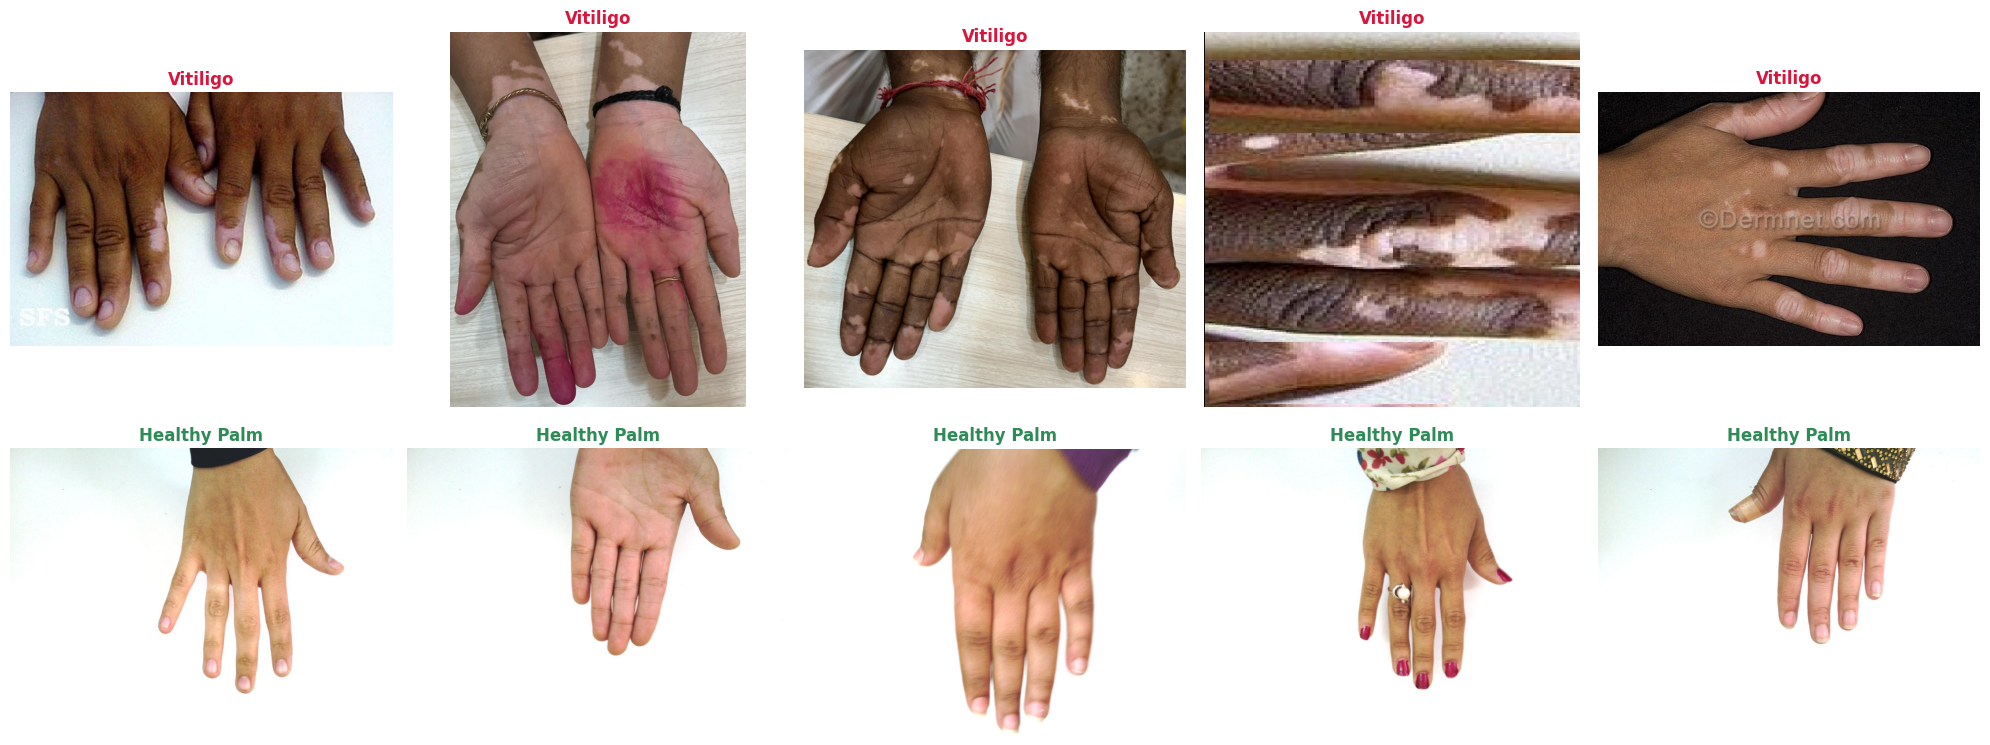


=== FINAL DATASET SUMMARY ===
Vitiligo: 301
Healthy Palm Control: 802


In [48]:
# Step: Show random sample from both Vitiligo and Healthy with class labels
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from pathlib import Path

vitiligo_files_final = list(Path("/kaggle/working/GLANCE_vitiligo/vitiligo_hand").glob("*.jpg"))
healthy_files_final = list(Path("/kaggle/working/GLANCE_vitiligo/healthy_hand").glob("*.jpg"))

import random
sample_vitiligo = random.sample(vitiligo_files_final, 5)
sample_healthy = random.sample(healthy_files_final, 5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, img_path in zip(axes.flat[:5], sample_vitiligo):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title("Vitiligo", fontsize=12, fontweight='bold', color='crimson')
    ax.axis('off')

for ax, img_path in zip(axes.flat[5:], sample_healthy):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title("Healthy Palm", fontsize=12, fontweight='bold', color='seagreen')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== FINAL DATASET SUMMARY ===")
print(f"Vitiligo: {len(vitiligo_files_final)}")
print(f"Healthy Palm Control: {len(healthy_files_final)}")